# CharaForge -- Colab Training Notebook

M4 onward runs here (model loading/quantization, LoRA layer, training loop, sampling) -- local dev machine has no usable GPU. Runtime: GPU (T4/L4/A100 depending on availability).

## Setup (infra -- run these as-is)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!git clone https://github.com/jmuelleo/CharaForge.git
%cd CharaForge

Cloning into 'CharaForge'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 77 (delta 25), reused 70 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 21.75 KiB | 10.87 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/CharaForge


In [3]:
!pip install -e ".[dev]" -q

# Editable installs aren't picked up by the already-running kernel until a
# restart -- this manually adds the src/ dir to sys.path so `import charlora`
# works immediately, no restart needed.
import sys
sys.path.insert(0, "/content/CharaForge/src")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 58.6 MB/s eta 0:00:00
  Building editable for charlora (pyproject.toml) ... done


In [4]:
from charlora.model.load import load_pipeline
from charlora.inference.sample import generate_image

pipe = load_pipeline()

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/494 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

The config attributes {'guidance_embeds': False, 'pooled_projection_dim': 768} were passed to ChromaTransformer2DModel, but are not expected and will be ignored. Please verify your config.json configuration file.
/usr/local/lib/python3.12/dist-packages/diffusers/models/embeddings.py:2617: FutureWarning: `FluxPosEmbed` is deprecated and will be removed in version 1.0.0. Importing and using `FluxPosEmbed` from `diffusers.models.embeddings` is deprecated. Please import it from `diffusers.models.transformers.transformer_flux`.
  deprecate("FluxPosEmbed", "1.0.0", deprecation_message)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/chroma/pipeline_chroma.py:516: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `ChromaPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/chroma/pipeline_chroma.py:543: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `ChromaPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


In [8]:
image = generate_image(pipe, prompt="1girl, frieren, white hair, green eyes, elf ears")
image

  0%|          | 0/40 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 37.44 MiB is free. Including non-PyTorch memory, this process has 39.45 GiB memory in use. Of the allocated memory 38.59 GiB is allocated by PyTorch, and 364.26 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [42]:
import torch
import gc #ist ein garbage collector module
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")

9.675805184 GB allocated


In [63]:
@torch.no_grad()
def generate_image(pipe, prompt, negative_prompt = "", steps = 40, guidance_scale = 3.0, seed = 0, height = 1024, width = 1024):
  gen = torch.Generator("cuda").manual_seed(seed)
  latents = pipe(prompt = prompt, negative_prompt = negative_prompt, height = height, width = width,
                  num_inference_steps = steps, guidance_scale = guidance_scale, generator = gen, output_type = "latent").images
  print(f"nach Denoising-Loop: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")
  print("NaN in latents:", torch.isnan(latents).any().item())
  print("Inf in latents:", torch.isinf(latents).any().item())
  print(latents.min().item(), latents.max().item(), latents.mean().item())
  latents = pipe._unpack_latents(latents, height, width, pipe.vae_scale_factor)
  latents = latents.to(torch.float32)
  latents = (latents / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
  generated_image = pipe.vae.tiled_decode(latents, return_dict = False)[0]
  generated_image = pipe.image_processor.postprocess(generated_image, output_type = "pil")
  return generated_image[0]

In [64]:
pipe.vae.tile_sample_min_size = 256
pipe.vae.tile_latent_min_size = 256 // pipe.vae_scale_factor  # = 32

  0%|          | 0/40 [00:00<?, ?it/s]

nach Denoising-Loop: 9.71 GB allocated
NaN in latents: False
Inf in latents: False
-5.09375 5.15625 0.2060546875


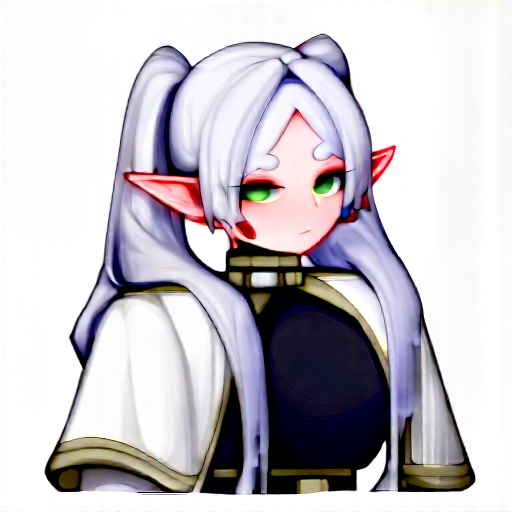

In [86]:
image = generate_image(pipe, prompt="1girl, frieren, white hair,artwork, art, green eyes, elf, elf ears, pointy ears, masterpiece, best quality, highly detailed, extremely detailed, sharp edges", height=512, width=512, steps = 40, guidance_scale = 5.0)
image

In [41]:
print("tile_sample_min_size:", pipe.vae.tile_sample_min_size)
print("tile_latent_min_size:", pipe.vae.tile_latent_min_size)
print("tile_overlap_factor:", pipe.vae.tile_overlap_factor)
print("vae_scale_factor:", pipe.vae_scale_factor)
print("latent_channels:", pipe.vae.config.latent_channels)


tile_sample_min_size: 128
tile_latent_min_size: 128
tile_overlap_factor: 0.25
vae_scale_factor: 8
latent_channels: 16


NameError: name 'latents' is not defined

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/40 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


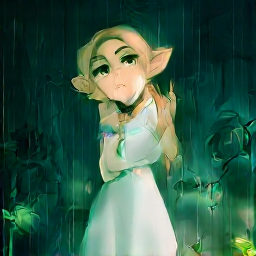

In [58]:
pipe.vae.to(torch.bfloat16)  # nur für diesen Test, dtype-match mit den Latents

gen = torch.Generator("cuda").manual_seed(0)
with torch.no_grad():
    image = pipe(prompt="a picture frieren, an elf with pointy ears, green eyes, wearing a white dress and dancing in the rain",
                 height=256, width=256, num_inference_steps=40, guidance_scale=3.0,
                 generator=gen).images[0]
pipe.vae.to(torch.float32)
image

In [46]:
import inspect
print(inspect.signature(pipe.vae.enable_tiling))
print(inspect.getsource(pipe.vae.enable_tiling))

()
    def enable_tiling(self):
        r"""
        Enable tiled VAE decoding. When this option is enabled, the VAE will split the input tensor into tiles to
        compute decoding and encoding in several steps. This is useful for saving a large amount of memory and to allow
        processing larger images.
        """
        if not hasattr(self, "use_tiling"):
            raise NotImplementedError(f"Tiling doesn't seem to be implemented for {self.__class__.__name__}.")
        self.use_tiling = True



In [62]:
import inspect
print(inspect.getsource(pipe.vae.tiled_decode))
print(pipe.vae.tile_sample_min_size, pipe.vae.tile_latent_min_size, pipe.vae.tile_overlap_factor)

    def tiled_decode(self, z: torch.Tensor, return_dict: bool = True) -> DecoderOutput | torch.Tensor:
        r"""
        Decode a batch of images using a tiled decoder.

        Args:
            z (`torch.Tensor`): Input batch of latent vectors.
            return_dict (`bool`, *optional*, defaults to `True`):
                Whether or not to return a [`~models.vae.DecoderOutput`] instead of a plain tuple.

        Returns:
            [`~models.vae.DecoderOutput`] or `tuple`:
                If return_dict is True, a [`~models.vae.DecoderOutput`] is returned, otherwise a plain `tuple` is
                returned.
        """
        overlap_size = int(self.tile_latent_min_size * (1 - self.tile_overlap_factor))
        blend_extent = int(self.tile_sample_min_size * self.tile_overlap_factor)
        row_limit = self.tile_sample_min_size - blend_extent

        # Split z into overlapping 64x64 tiles and decode them separately.
        # The tiles have an overlap to avoid seams betwe